In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def parse_line(line):
    tokens = line.split() #line.split()  Split the line into tokens
    key=['Time', 'Etot', 'Epot', 'Ekin', 'T', 'stress1', 'stress2', 'stress3', 'stress4', 'stress5', 'stress6']
    data = {}
    i = 0
    while i < len(tokens):
        value = tokens[i]

        # Remove trailing 's' from Time
        if value.endswith('s'):
            value = value[:-1]

        # Try to convert to int or float
        try:
            if '.' in value:
                value = float(value)
            else:
                value = int(value)
        except ValueError:
            pass

        data[key[i]] = value
        i += 1 

    return data



results = []
with open("./md.log", "r", encoding="utf-8") as f:
    next(f)  # Skip the first line
    for line in f:
        results.append(parse_line(line)) #la salida es una lista de diccionarios, donde cada diccionario contiene los datos de una línea del log

keys = results[0].keys()
array = np.array([[row[k] for k in keys] for row in results])

def running_avg(x, w):
    cumsum = np.cumsum(np.insert(x, 0, 0)) #introduce un 0 al principio de la suma acumulativa para facilitar el cálculo del promedio
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        start = max(0, i - w + 1)
        count = i - start + 1
        out[i] = (cumsum[i+1] - cumsum[start]) / count
    return out



In [13]:
colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

everyN=10
window = 500

time = array[::everyN, 0]
Etot = array[::everyN, 1]
Epot = array[::everyN, 2]
Ekin = array[::everyN, 3]
temp = array[::everyN, 4]
stress1=array[::everyN, 5]

Etot_avg = running_avg(Etot, window)
Epot_avg = running_avg(Epot, window)
Ekin_avg = running_avg(Ekin, window)
temp_avg = running_avg(temp, window)
s1_avg = running_avg(stress1, window)


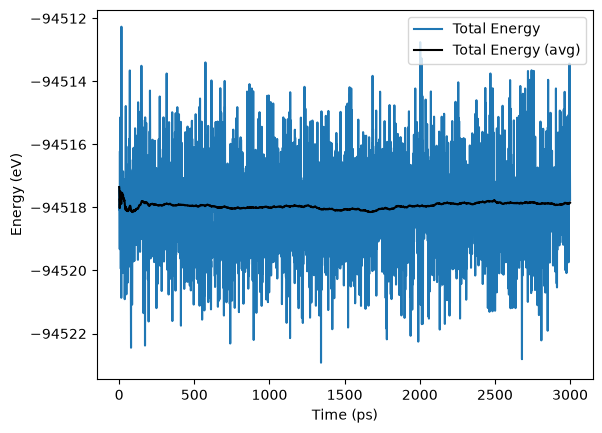

In [14]:
#Energía total

plt.figure()
plt.plot(time, Etot, label='Total Energy', color=colors[0], alpha=1)
plt.plot(time, Etot_avg, label='Total Energy (avg)', color='black', alpha=1)
plt.xlabel("Time (ps)")
plt.ylabel("Energy (eV)")
plt.legend()
plt.show()

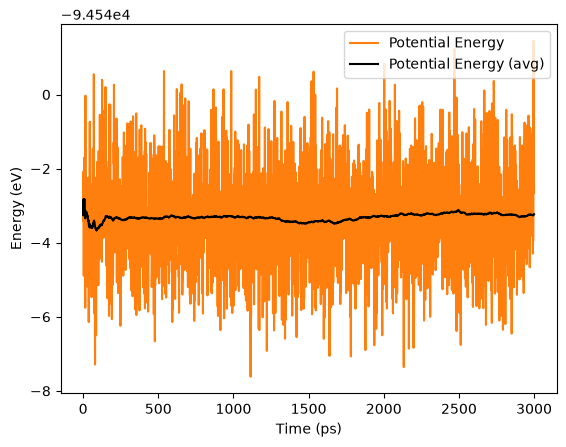

In [15]:
# Energía potencial

plt.figure()
plt.plot(time, Epot, label='Potential Energy', color=colors[1], alpha=1)
plt.plot(time, Epot_avg, label='Potential Energy (avg)', color='black', alpha=1)
plt.xlabel("Time (ps)")
plt.ylabel("Energy (eV)")
plt.legend()
plt.show()

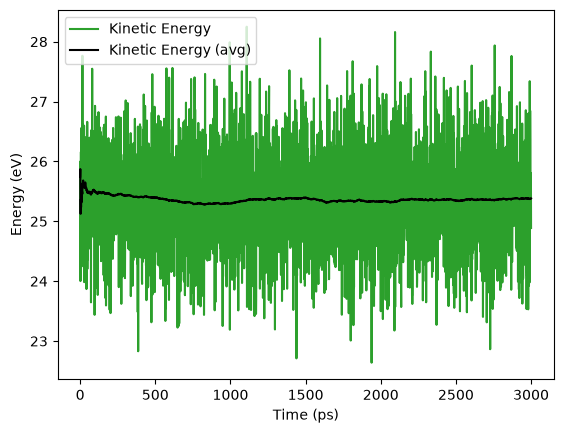

In [16]:
# Energía cinetica

plt.figure()
plt.plot(time, Ekin, label='Kinetic Energy', color=colors[2], alpha=1)
plt.plot(time, Ekin_avg, label='Kinetic Energy (avg)', color='black', alpha=1)
plt.xlabel("Time (ps)")
plt.ylabel("Energy (eV)")
plt.legend()
plt.show()

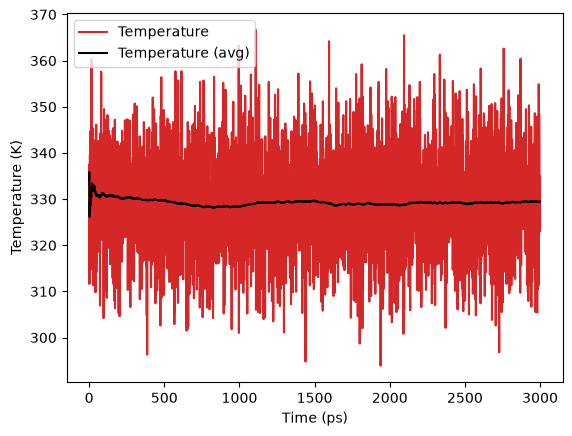

In [17]:
# Temperatura

plt.figure()
plt.plot(time, temp, label='Temperature', color=colors[3], alpha=1)
plt.plot(time, temp_avg, label='Temperature (avg)', color='black', alpha=1)
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.show()

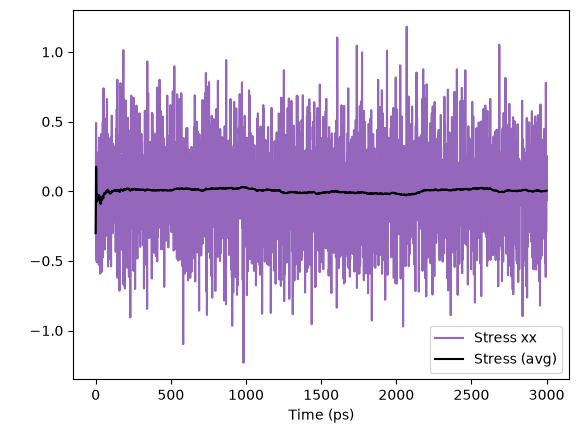

In [18]:
plt.figure()
plt.plot(time, stress1, label='Stress xx', color=colors[4], alpha=1)
plt.plot(time, s1_avg, label='Stress (avg)', color='black', alpha=1)
plt.xlabel("Time (ps)")
plt.ylabel(" ")
plt.legend()
plt.show()

In [ ]:
from ase.io import read
from IPython.display import display

atoms = read('md.xyz',index=0) #frame inicial

try:
    import nglview as nv
    view = nv.show_ase(atoms)
    display(view)
    view
except ImportError:
    from ase.visualize import view as ase_view
    ase_view(atoms)


NGLWidget()

In [2]:
atoms.get_cell()

Cell([17.79514440999267, 17.79514440999267, 17.79514440999267])